# Pneumonia Detection from Chest X-Ray Images using CNN

## Project Objective

This project builds a **Deep Learning CNN model** to classify chest X-ray images into:

| Class | Meaning |
|---|---|
| NORMAL | Patient does not show pneumonia signs |
| PNEUMONIA | Patient shows pneumonia signs |

## Project Flow

```text
Download Dataset
↓
Set Dataset Path
↓
Load Train / Validation / Test Images
↓
Apply Image Preprocessing and Augmentation
↓
Build CNN Model
↓
Train Model
↓
Evaluate Model
↓
Generate Confusion Matrix and Classification Report
↓
Predict Single X-Ray Image
↓
Save Model
```

## Dataset

Recommended dataset:

```text
Chest X-Ray Images Pneumonia Dataset
```

Kaggle link:

```text
https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
```

Expected folder structure:

```text
chest_xray/
│
├── train/
│   ├── NORMAL/
│   └── PNEUMONIA/
│
├── val/
│   ├── NORMAL/
│   └── PNEUMONIA/
│
└── test/
    ├── NORMAL/
    └── PNEUMONIA/
```

## Step 1: Install Required Libraries

Run this cell only if libraries are not installed.

In [1]:
# Uncomment and run only if required
# !pip install tensorflow matplotlib numpy scikit-learn pillow

## Step 2: Import Libraries

In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing import image

from sklearn.metrics import classification_report, confusion_matrix

print("Libraries imported successfully")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully
TensorFlow version: 2.21.0


## Step 3: Set Dataset Path

Update `DATASET_PATH` according to your laptop folder location.

Example:

```python
DATASET_PATH = r"E:\Rahul Verma\document\D drive\PROJECTS\Vscode\DeepLearning\chest_xray"
```

In [4]:
DATASET_PATH = r"E:\Rahul Verma\document\D drive\PROJECTS\Vscode\Deeplearning\chest_xray\chest_xray"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VAL_DIR = os.path.join(DATASET_PATH, "val")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Train path:", TRAIN_DIR)
print("Val path:", VAL_DIR)
print("Test path:", TEST_DIR)

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Val exists:", os.path.exists(VAL_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

print("Train folders:", os.listdir(TRAIN_DIR))
print("Val folders:", os.listdir(VAL_DIR))
print("Test folders:", os.listdir(TEST_DIR))

Train path: E:\Rahul Verma\document\D drive\PROJECTS\Vscode\Deeplearning\chest_xray\chest_xray\train
Val path: E:\Rahul Verma\document\D drive\PROJECTS\Vscode\Deeplearning\chest_xray\chest_xray\val
Test path: E:\Rahul Verma\document\D drive\PROJECTS\Vscode\Deeplearning\chest_xray\chest_xray\test
Train exists: True
Val exists: True
Test exists: True
Train folders: ['.DS_Store', 'NORMAL', 'PNEUMONIA']
Val folders: ['.DS_Store', 'NORMAL', 'PNEUMONIA']
Test folders: ['NORMAL', 'PNEUMONIA']


## Step 4: Check Dataset Folder Structure

This step confirms whether train, validation, and test folders are available.

In [5]:
required_dirs = [TRAIN_DIR, VAL_DIR, TEST_DIR]

for folder in required_dirs:
    if not os.path.exists(folder):
        print("Missing folder:", folder)
    else:
        print("Found folder:", folder)

for split_name, split_dir in [("Train", TRAIN_DIR), ("Validation", VAL_DIR), ("Test", TEST_DIR)]:
    print(f"\n{split_name} folder class count:")
    if os.path.exists(split_dir):
        for class_name in os.listdir(split_dir):
            class_path = os.path.join(split_dir, class_name)
            if os.path.isdir(class_path):
                print(class_name, ":", len(os.listdir(class_path)))

Found folder: E:\Rahul Verma\document\D drive\PROJECTS\Vscode\Deeplearning\chest_xray\chest_xray\train
Found folder: E:\Rahul Verma\document\D drive\PROJECTS\Vscode\Deeplearning\chest_xray\chest_xray\val
Found folder: E:\Rahul Verma\document\D drive\PROJECTS\Vscode\Deeplearning\chest_xray\chest_xray\test

Train folder class count:
NORMAL : 1342
PNEUMONIA : 3876

Validation folder class count:
NORMAL : 9
PNEUMONIA : 9

Test folder class count:
NORMAL : 234
PNEUMONIA : 390


## Step 5: Image Settings

We resize all X-ray images to `150 x 150`.

`BATCH_SIZE = 32` means the model processes 32 images at a time.

In [6]:
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

## Step 6: Data Augmentation and Preprocessing

### Why augmentation?

Medical image datasets can be limited. Augmentation creates small variations of training images and helps reduce overfitting.

Training images are augmented using:

- Rotation
- Zoom
- Width shift
- Height shift
- Horizontal flip

Validation and test images are only rescaled.

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_val_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

## Step 7: Load Images from Folders

`flow_from_directory()` automatically reads images from class-wise folders.

Expected classes:

```text
NORMAL
PNEUMONIA
```

In [8]:
train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = test_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Class Labels:", train_data.class_indices)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class Labels: {'NORMAL': 0, 'PNEUMONIA': 1}


## Step 8: Show Sample Images

This helps us visually check that images are loading correctly.

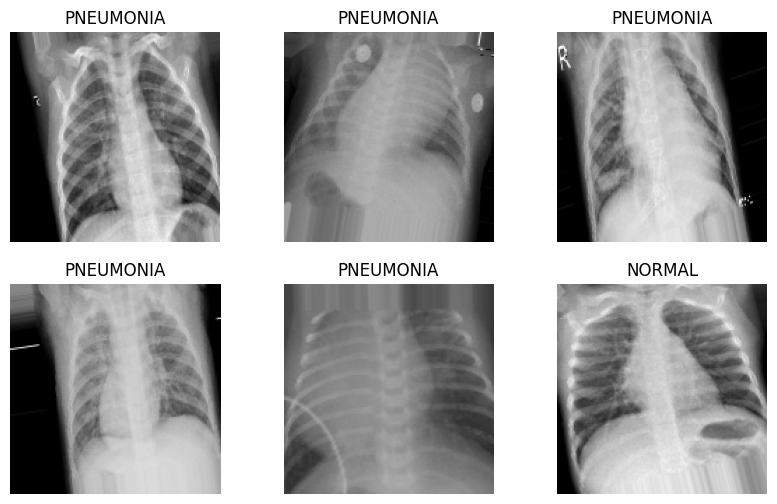

In [9]:
images, labels = next(train_data)

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    label = "PNEUMONIA" if labels[i] == 1 else "NORMAL"
    plt.title(label)
    plt.axis("off")

plt.show()

## Step 9: Build CNN Model

CNN is useful for image classification because it learns image features such as:

- Edges
- Shapes
- Patterns
- Texture differences

### Model layers used

| Layer | Purpose |
|---|---|
| Conv2D | Extract image features |
| BatchNormalization | Stabilize training |
| MaxPooling2D | Reduce image size and computation |
| Flatten | Convert feature maps into 1D vector |
| Dense | Classification learning |
| Dropout | Reduce overfitting |
| Sigmoid | Binary classification output |

In [10]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 10: Compile Model

Since this is a binary classification problem, we use:

```text
loss = binary_crossentropy
activation = sigmoid
```

In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,377 (18.42 MB)

 Trainable params: 4,828,929 (18.42 MB)

 Non-trainable params: 448 (1.75 KB)

## Step 11: Add Callbacks

### EarlyStopping

Stops training when validation loss is not improving.

### ModelCheckpoint

Saves the best model based on validation accuracy.

In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_pneumonia_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

## Step 12: Train Model

You can increase `epochs` for better training, but it may take more time.

In [14]:
history = model.fit(
    train_data,
    epochs=15,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8047 - loss: 1.1137

163/163 ━━━━━━━━━━━━━━━━━━━━ 224s 1s/step - accuracy: 0.8376 - loss: 0.5315 - val_accuracy: 0.5000 - val_loss: 59.7850
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 144s 877ms/step - accuracy: 0.8692 - loss: 0.3339 - val_accuracy: 0.5000 - val_loss: 37.9576
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 172s 697ms/step - accuracy: 0.8865 - loss: 0.2831 - val_accuracy: 0.5000 - val_loss: 13.5247
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.9086 - loss: 0.2316 - val_accuracy: 0.5000 - val_loss: 24.0752
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 237s 1s/step - accuracy: 0.9176 - loss: 0.2121 - val_accuracy: 0.5000 - val_loss: 1.7781
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9277 - loss: 0.1927 - val_accuracy: 0.5000 - val_loss: 1.3691
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.9298 - loss: 0.1952 - val_accuracy: 0.4375 - val_loss: 1.6219
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9226 - loss: 0.2066

163/163 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.9183 - loss: 0.2400 - val_accuracy: 0.6250 - val_loss: 12.5138
Epoch 9/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.9151 - loss: 0.2367 - val_accuracy: 0.5000 - val_loss: 0.6861
Epoch 10/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.9279 - loss: 0.1884 - val_accuracy: 0.5000 - val_loss: 81.4515
Epoch 11/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.9266 - loss: 0.1958 - val_accuracy: 0.5000 - val_loss: 7.2300
Epoch 12/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9321 - loss: 0.1845

163/163 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.9287 - loss: 0.1937 - val_accuracy: 0.8125 - val_loss: 0.4362
Epoch 13/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.9329 - loss: 0.1785 - val_accuracy: 0.5625 - val_loss: 9.6296
Epoch 14/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.9247 - loss: 0.2147 - val_accuracy: 0.5625 - val_loss: 0.6975
Epoch 15/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.9191 - loss: 0.2274 - val_accuracy: 0.5625 - val_loss: 34.1892


## Step 13: Evaluate Model on Test Data

In [15]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8910 - loss: 0.2705
Test Loss: 0.27054861187934875
Test Accuracy: 0.8910256624221802


## Step 14: Prediction on Test Data

The model returns probabilities.

If probability is greater than `0.5`, prediction is `PNEUMONIA`, else `NORMAL`.

In [16]:
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

y_true = test_data.classes

print("Prediction completed")

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 808ms/step
Prediction completed


## Step 15: Confusion Matrix and Classification Report

In [22]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))


Confusion Matrix:
[[198  36]
 [ 32 358]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.86      0.85      0.85       234
   PNEUMONIA       0.91      0.92      0.91       390

    accuracy                           0.89       624
   macro avg       0.88      0.88      0.88       624
weighted avg       0.89      0.89      0.89       624



## Step 16: Confusion Matrix Visualization

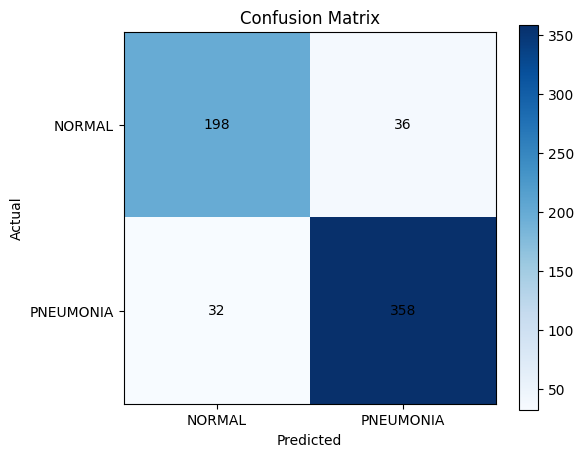

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["NORMAL", "PNEUMONIA"]
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Step 17: Accuracy Graph

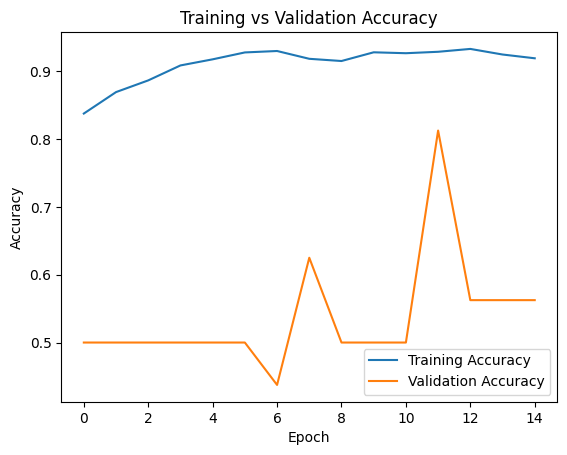

In [24]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

## Step 18: Loss Graph

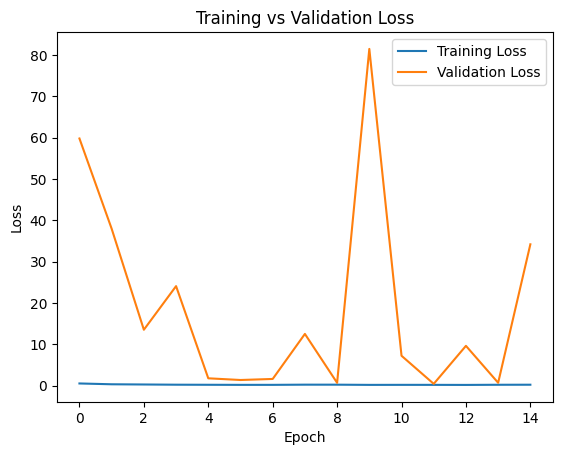

In [25]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

## Step 19: Save Final Model

In [26]:
model.save("pneumonia_cnn_model.h5")

print("Model saved successfully as pneumonia_cnn_model.h5")

Model saved successfully as pneumonia_cnn_model.h5


## Step 20: Load Saved Model

This confirms that the saved model can be reused later.

In [27]:
loaded_model = load_model("pneumonia_cnn_model.h5")

print("Model loaded successfully")

Model loaded successfully


## Step 21: Predict One New X-Ray Image

Change `IMAGE_PATH` to any test image path from your dataset.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step


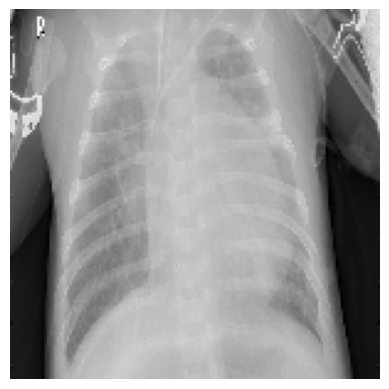

Prediction: PNEUMONIA
Confidence Score: 0.99999994


In [29]:
IMAGE_PATH = r"E:\Rahul Verma\document\D drive\PROJECTS\Vscode\Deeplearning\chest_xray\chest_xray\test\PNEUMONIA\person1_virus_7.jpeg"

if not os.path.exists(IMAGE_PATH):
    print("Image path not found. Please update IMAGE_PATH.")
else:
    img = image.load_img(
        IMAGE_PATH,
        target_size=IMAGE_SIZE
    )

    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = loaded_model.predict(img_array)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    if prediction[0][0] > 0.5:
        print("Prediction: PNEUMONIA")
    else:
        print("Prediction: NORMAL")

    print("Confidence Score:", prediction[0][0])

## Step 22: Interview Explanation

You can explain this project like this:

> I built a healthcare image classification project for pneumonia detection from chest X-ray images.  
> I used a public chest X-ray dataset with two classes: NORMAL and PNEUMONIA.  
> I performed image preprocessing, normalization, and data augmentation.  
> I built a CNN model using convolution, max-pooling, batch normalization, dropout, and dense layers.  
> The model predicts whether a chest X-ray image is normal or pneumonia.  
> I evaluated the model using accuracy, confusion matrix, precision, recall, and F1-score.  
> Finally, I saved the trained model and tested it on a new X-ray image.

## Important Notes

1. This model is for learning and project demonstration only.
2. It should not be used for real medical diagnosis.
3. Medical AI requires expert validation, clinical testing, and regulatory approval.
4. For better accuracy, you can use transfer learning with models like VGG16, ResNet50, EfficientNet, or DenseNet.